# chapter 5. 오차역전파법
앞 장에서는 신경망 학습에 대해서 설명하였고, 신경망의 가중치 매개변수 기울기(정확히는 가중치 매개변수에 대한 손실 함수의 기울기)를 수치 미분을 사용해 구하였음\
수치 미분은 단순하고 구현하기도 쉽지만 계산 시간이 오래 걸린다는 단점이 존재함\
이번 장에서는 가중치 매개변수의 기울기를 효율적으로 계산하는 '오차역전파법(backpropagtation)'을 배울 것임

## 5.1 계산 그래프
`계산 그래프(computational graph)`는 이름 그대로 계산 과정을 표현한 그래프임\
여기에서의 그래프는 복수의 `노드(node)`와 `에지(edge)`로 표현됨

In [4]:
import matplotlib
matplotlib.rc('font', family='AppleGothic')   # macOS 한글 폰트
matplotlib.rc('axes', unicode_minus=False)    # 마이너스 기호 깨짐 방지


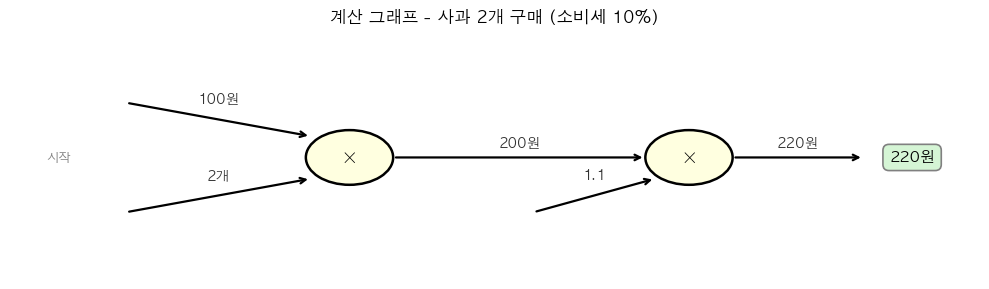

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# ── 노드 그리기 (원 안에 연산 표시) ──────────────────────────────
def draw_node(ax, x, y, text, r=0.45):
    circle = plt.Circle((x, y), r, fc='lightyellow', ec='black', lw=1.8, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, text, ha='center', va='center', fontsize=14, zorder=4)

draw_node(ax, 3.5, 2.0, '×')   # 사과가격 × 개수
draw_node(ax, 7.0, 2.0, '×')   # 소계 × 소비세

# ── 화살표 그리기 (엣지) ─────────────────────────────────────────
def draw_arrow(ax, x0, y0, x1, y1, label='', label_offset=(0, 0.22)):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.6))
    mx, my = (x0 + x1) / 2 + label_offset[0], (y0 + y1) / 2 + label_offset[1]
    if label:
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=10, color='#333333')

# 사과 가격 (위쪽 입력)
draw_arrow(ax, 1.2, 2.9,  3.1, 2.35, label='100원')
# 개수 (아래쪽 입력) — 노드 안은 ×, 엣지에 2개 표시
draw_arrow(ax, 1.2, 1.1,  3.1, 1.65, label='2개')
# ×1 → ×2 중간 결과
draw_arrow(ax, 3.95, 2.0, 6.55, 2.0, label='200원', label_offset=(0, 0.12))
# 소비세 (아래쪽 입력)
draw_arrow(ax, 5.4, 1.1,  6.65, 1.65, label='1.1')
# ×2 → 결과
draw_arrow(ax, 7.45, 2.0, 8.8, 2.0, label='220원', label_offset=(0, 0.12))

# ── 시작 라벨 ────────────────────────────────────────────────────
ax.text(0.5, 2.0, '시작', ha='center', va='center', fontsize=9, color='gray')

# ── 결과 박스 ────────────────────────────────────────────────────
ax.text(9.3, 2.0, '220원', ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', fc='#d5f5d5', ec='gray', lw=1.2))

plt.title('계산 그래프 - 사과 2개 구매 (소비세 10%)', fontsize=12, pad=10)
plt.tight_layout()
plt.show()


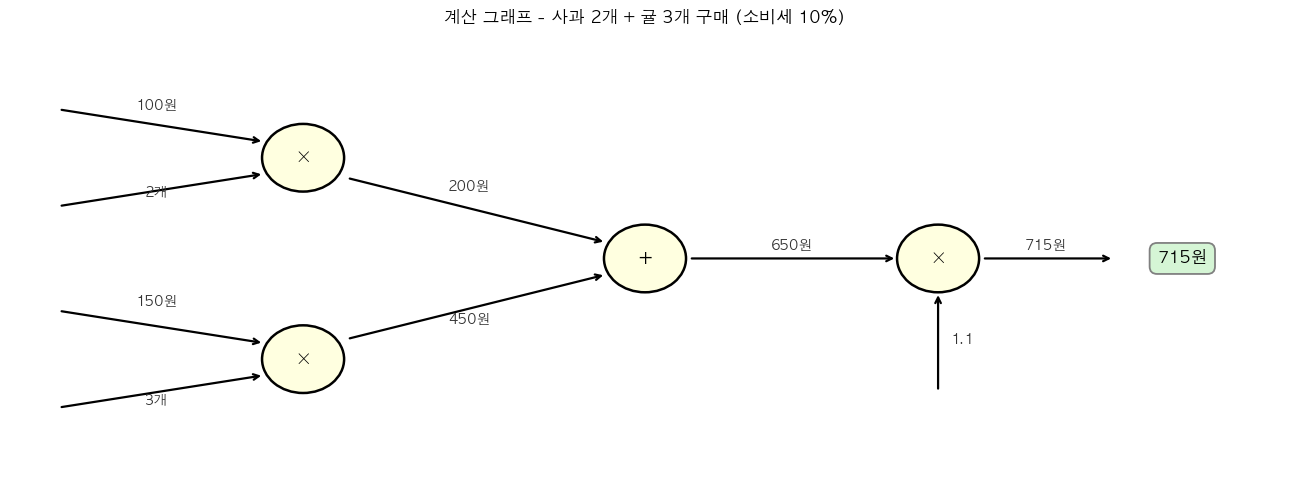

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5.5)
ax.axis('off')

# ── 헬퍼 함수 ────────────────────────────────────────────────────
def draw_node(ax, x, y, text, r=0.42, fc='lightyellow'):
    circle = plt.Circle((x, y), r, fc=fc, ec='black', lw=1.8, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, text, ha='center', va='center', fontsize=14, zorder=4)

def draw_arrow(ax, x0, y0, x1, y1, label='', lx=None, ly=None):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.6))
    if label:
        mx = lx if lx is not None else (x0 + x1) / 2
        my = ly if ly is not None else (y0 + y1) / 2 + 0.18
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=10, color='#333')

# ── 노드 위치 ────────────────────────────────────────────────────
#  사과: ×(100×2)  at (3.0, 4.0)
#  귤:  ×(150×3)  at (3.0, 1.5)
#  합산: +         at (6.5, 2.75)
#  세금: ×(×1.1)  at (9.5, 2.75)

draw_node(ax, 3.0, 4.0, '×')          # 사과 곱셈
draw_node(ax, 3.0, 1.5, '×')          # 귤 곱셈
draw_node(ax, 6.5, 2.75, '+')         # 덧셈
draw_node(ax, 9.5, 2.75, '×')         # 소비세 곱셈

# ── 입력 → 사과 × 노드 ──────────────────────────────────────────
draw_arrow(ax, 0.5, 4.6,  2.6, 4.2,  label='100원', lx=1.5, ly=4.55)
draw_arrow(ax, 0.5, 3.4,  2.6, 3.8,  label='2개',   lx=1.5, ly=3.48)

# ── 입력 → 귤 × 노드 ────────────────────────────────────────────
draw_arrow(ax, 0.5, 2.1,  2.6, 1.7,  label='150원', lx=1.5, ly=2.12)
draw_arrow(ax, 0.5, 0.9,  2.6, 1.3,  label='3개',   lx=1.5, ly=0.9)

# ── 사과 × → + ──────────────────────────────────────────────────
draw_arrow(ax, 3.45, 3.75, 6.1, 2.95, label='200원', lx=4.7, ly=3.55)

# ── 귤 × → + ────────────────────────────────────────────────────
draw_arrow(ax, 3.45, 1.75, 6.1, 2.55, label='450원', lx=4.7, ly=1.9)

# ── + → 소비세 × ────────────────────────────────────────────────
draw_arrow(ax, 6.95, 2.75, 9.08, 2.75, label='650원', lx=8.0, ly=2.82)

# ── 소비세 입력 ──────────────────────────────────────────────────
draw_arrow(ax, 9.5, 1.1,  9.5, 2.33,  label='1.1',   lx=9.75, ly=1.65)

# ── 소비세 × → 결과 ─────────────────────────────────────────────
draw_arrow(ax, 9.95, 2.75, 11.3, 2.75, label='715원', lx=10.6, ly=2.82)

# ── 결과 박스 ────────────────────────────────────────────────────
ax.text(12.0, 2.75, '715원', ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.45', fc='#d5f5d5', ec='gray', lw=1.3))

plt.title('계산 그래프 - 사과 2개 + 귤 3개 구매 (소비세 10%)', fontsize=12, pad=10)
plt.tight_layout()
plt.show()


### 5.1.1 계산 그래프로 풀다
계산 그래프를 이용한 문제풀이는 다음 흐름으로 진행함
1. 계산 그래프를 구성함
2. 그래프에서 계산을 왼쪽에서 오른쪽으로 진행함

여기에서 2번째 '계산을 왼쪽에서 오른쪽으로 진행'하는 단계를 `순전파(forward propagation)`라고 함\
순전파는 계산 그래프의 출발점부터 종착점으로의 전파임\
순전파의 반대(오른쪽에서 왼쪽)의 전파는 `역전파(backward propagtion)`라고 하며 역전파는 미분을 계산할 때 중요한 역할을 함

### 5.1.2 국소적 계산
계산 그래프의 특징은 '국소적 계산'을 전파함으로써 최종 결과를 얻는다는 점에 있음\
국소적이란 '자신과 직접 관계된 작은 범위'라는 뜻이며, 국소적 계산은 결국 전체에서 어떤 일이 벌어지든 상관없이 자신과 관계된 정보만으로 결과를 출력함

예를들어서 슈퍼마켓에서 여러 식품을 구매하는데 4000원이 들었고 사과 2개까지 추가한다고 가정해보자\
여러 식품을 구입하여 (복잡한 계산을 거쳐) 총 금액이 4000원이 되었음\
여기에서 핵심은 각 노드에서의 계산은 국소적 계산이라는 점이며, 가령 사과와 그외의 물품 값을 더하는 계산은 4000이라는 숫자가 어떻게 계산되었느냐와는 상관없이 단지 두 숫자를 더하면 된다는 뜻임\
각 노드는 자신과 관련한 계산(이 가정에서는 입력된 두 숫자의 덧셈(4000 + 200)) 외에는 신경 쓸 것이 없음\
이처럼 계산 그래프는 국소적 계산에 집중하기에 전체 계산이 아무리 복잡하더라도 각 단계에서 하는 일은 해당 노드의 '국소적 계산'임

### 5.1.3 왜 계산 그래프로 푸는가?
계산 그래프의 이점은 '국소적 계산'이기에 전체가 아무리 복잡해도 각 노드에서는 단순한 계산에 집중하여 문제를 단순화할 수 있음\
다른 이점으로, 계산 그래프는 중간 계산 결과를 모두 보관할 수 있음\
예를 들어 사과 2개까지 계산했을 때의 금액은 200원, 소비세를 더하기 전의 금액은 650원임\
실제 계산 그래프를 사용하는 가장 큰 이유는 역전파를 통해 '미분'을 효율적으로 계산할 수 있는 점에 있음

계산 그래프의 역전파를 설명하기 위해 문제 1을 다시 보면, 문제 1은 사과 2개를 사서 소비세를 포함한 최종 금액을 구하는 문제임\
여기서 가령 사과 가격이 오르면 최종 금액에 어떤 영향을 끼치는지 알고 싶다고 가정하자\
이는 '사과 가격에 대한 지불 금액의 미분'을 구하는 문제에 해당함\
기호로 나타낸다면 사과 값을 $x$, 지불 금액을 $L$ 이라 했을 때 $\frac{\partial L}{\partial x}$ 을 구하는 것\
이 미분 값은 사과 값이 '아주 조금' 올랐을 때의 최종 지불 금액 증가량임

'사과 가격에 대한 지불 금액의 미분'같은 값은 계산 그래프에서 역전파를 하면 구할 수 있음

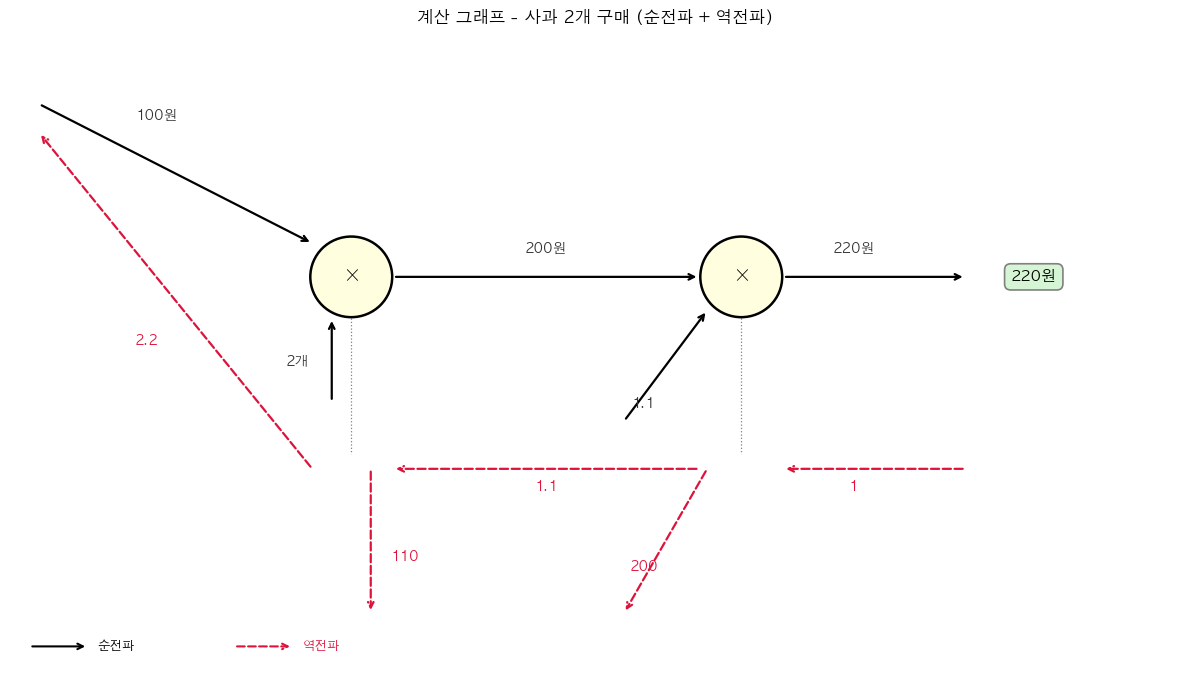

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0.3, 7)
ax.axis('off')

# ── 헬퍼 ─────────────────────────────────────────────────────────
def draw_node(ax, x, y, text, r=0.42):
    circle = plt.Circle((x, y), r, fc='lightyellow', ec='black', lw=1.8, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, text, ha='center', va='center', fontsize=15, zorder=4)

def fwd(ax, x0, y0, x1, y1, label='', lx=None, ly=None):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.6))
    if label:
        mx = lx if lx is not None else (x0 + x1) / 2
        my = ly if ly is not None else (y0 + y1) / 2 + 0.22
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=10, color='#333')

def bwd(ax, x0, y0, x1, y1, label='', lx=None, ly=None):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.6,
                                linestyle='dashed'))
    if label:
        mx = lx if lx is not None else (x0 + x1) / 2
        my = ly if ly is not None else (y0 + y1) / 2 - 0.22
        ax.text(mx, my, label, ha='center', va='top', fontsize=10, color='crimson')

# 노드 좌표 및 역전파 트랙 높이
NX1, NX2, NY = 3.5, 7.5, 4.5
BWD = 2.5   # 역전파 수평 트랙 y

draw_node(ax, NX1, NY, '×')   # ×1: 가격 × 개수
draw_node(ax, NX2, NY, '×')   # ×2: 소계 × 소비세

# ════ 순전파 (검정) ════════════════════════════════════════════════
# 가격 100원 → ×1 (위 대각선)
fwd(ax, 0.3, 6.3,  3.1,  NY+0.35, label='100원', lx=1.5, ly=6.1)
# 개수 2개  → ×1 (아래 수직선 – bwd 트랙 위에서 시작)
fwd(ax, 3.3, BWD+0.7, 3.3, NY-0.43, label='2개', lx=2.95, ly=3.55)
# ×1 → ×2  (수평)
fwd(ax, NX1+0.43, NY, NX2-0.43, NY, label='200원', lx=5.5, ly=NY+0.22)
# 소비세 1.1 → ×2 (아래 대각선 – bwd 트랙 위에서 시작)
fwd(ax, 6.3, BWD+0.5, NX2-0.35, NY-0.35, label='1.1', lx=6.5, ly=3.1)
# ×2 → 결과 (수평)
fwd(ax, NX2+0.43, NY, 9.8, NY, label='220원', lx=8.65, ly=NY+0.22)

# 결과 박스
ax.text(10.5, NY, '220원', ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', fc='#d5f5d5', ec='gray', lw=1.2))

# ════ 역전파 트랙 (빨강) ═══════════════════════════════════════════
# 노드 → 역전파 트랙으로 수직 점선 연결
ax.plot([NX1, NX1], [NY-0.43, BWD+0.15], color='gray', lw=0.9, ls=':', zorder=2)
ax.plot([NX2, NX2], [NY-0.43, BWD+0.15], color='gray', lw=0.9, ls=':', zorder=2)

# 결과 → ×2  (수평 역전파 트랙)
bwd(ax, 9.8,          BWD,  NX2+0.43, BWD,  label='1',   lx=8.65, ly=BWD-0.12)
# ×2 → ×1  (수평 역전파 트랙)
bwd(ax, NX2-0.43,     BWD,  NX1+0.43, BWD,  label='1.1', lx=5.5,  ly=BWD-0.12)
# ×1 → 가격 (위 대각선 – fwd 가격과 교차 없이 바깥으로)
bwd(ax, 3.1,          BWD,  0.3, 6.0,        label='2.2', lx=1.4,  ly=3.9)
# ×1 → 개수 (아래 수직선 – fwd 개수와 x 살짝 오른쪽으로 분리)
bwd(ax, 3.7,          BWD,  3.7, 1.0,        label='110', lx=4.05, ly=1.65)
# ×2 → 소비세 (아래 대각선 – fwd 소비세와 y 범위 분리)
bwd(ax, NX2-0.35,     BWD,  6.3, 1.0,        label='200', lx=6.5,  ly=1.55)

# ── 범례 ─────────────────────────────────────────────────────────
ax.annotate('', xy=(0.8, 0.65), xytext=(0.2, 0.65),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(0.9, 0.65, '순전파', va='center', fontsize=9, color='black')
ax.annotate('', xy=(2.9, 0.65), xytext=(2.3, 0.65),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5,
                            linestyle='dashed'))
ax.text(3.0, 0.65, '역전파', va='center', fontsize=9, color='crimson')

plt.title('계산 그래프 - 사과 2개 구매 (순전파 + 역전파)', fontsize=12, pad=10)
plt.tight_layout()
plt.show()


역전파는 순전파와는 반대 방향의 화살표로 그림\
이 전파는 '국소적 미분'을 전달하고 미분 값을 적음\
이 예시에서 역전파는 오른쪽에서 왼쪽으로 '1 $\rightarrow$ 1.1 $\rightarrow$ 2.2'순으로 미분 값을 전달함\
이 결과로부터 '사과 가격에 대한 지불 금액의 미분'값은 2.2라 할 수 있음\
사과가 1원 오르면 최종 금액은 2.2원 오른다는 뜻(정확히는 사과 값이 아주 조금 오르면 최종 금액은 그 아주 작은 값의 2.2배만큼 오름)

여기에서는 사과 가격에 대한 미분만 구했지만 '소비세에 대한 지불 금액의 미분'이나 '사과 개수에 대한 지불 금액의 미분'도 같은 순서로 구할 수 있음\
그리고 그때는 중간까지 구한 미분 결과를 공유할 수 있어서 다수의 미분을 효율적으로 계산할 수 있음\
이처럼 계산 그래프의 이점은 순전파와 역전파를 활용해서 각 변수의 미분을 효율적으로 구할 수 있다는 것

## 5.2 연쇄법칙
